In [12]:
# ======================================================================
# 👍 1. 디버그용 출력 함수 (오류 위치 정확히 찍어줌)
# ======================================================================
import numpy as np
import joblib
import random
import time
import os
import cv2

from scipy.ndimage import rotate, shift, zoom
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

def debug(msg):
    print(f"🔎 DEBUG >> {msg}")

In [13]:
# ======================================================================
# 2. 사용자 정의 전처리 클래스
# ======================================================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target
        self.target_size = target_size
        self.final_size = final_size
        self.noise_threshold = noise_threshold    

    def fit(self, X, y=None): return self

    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:  # 784 형태인 경우
            X = X.reshape(-1, 28, 28)
        processed = []

        for img in X:
            img = img.astype(np.float32)
            img = img / 255.0 if img.max() > 1 else img
            img[img < self.noise_threshold] = 0.0
            mask = img > 0.10
            if mask.sum() > 0:
                img = img * (self.stroke_target / img[mask].mean())
            img = np.clip(img, 0, 1)

            coords = np.where(img > 0.10)
            if coords[0].size > 0:
                r1, r2 = coords[0].min(), coords[0].max()
                c1, c2 = coords[1].min(), coords[1].max()
                digit = img[r1:r2+1, c1:c2+1]
                zoom_factor_h, zoom_factor_w = 20 / digit.shape[0], 20 / digit.shape[1]
                digit = zoom(digit, (zoom_factor_h, zoom_factor_w))
            else:
                digit = np.zeros((28, 28))

            canvas = np.zeros((28, 28))
            h, w = digit.shape
            y0, x0 = (28 - h) // 2, (28 - w) // 2
            canvas[y0:y0+h, x0:x0+w] = digit
            processed.append(canvas)

        return np.array(processed).reshape(len(processed), -1)


In [4]:
# ======================================================================
# 3. 증강 함수
# ======================================================================
def apply_augment_single(img, mode):
    img = img.reshape(28, 28).astype(np.float32)
    if mode == 'rotate':
        img = rotate(img, random.uniform(-15, 15), reshape=False, mode='constant')
    elif mode == 'shift':
        img = shift(img, [random.uniform(-2, 2), random.uniform(-2, 2)], mode='constant')
    elif mode == 'zoom':
        factor = random.uniform(1.0, 1.1)
        img = zoom(img, factor)
        img = img[:28, :28]
    return cv2.resize(img, (28, 28))

In [5]:
# ======================================================================
# 4. 데이터 로드 + 전처리
# ======================================================================
def load_preprocess_and_augment(hand_path, org_path):
    try:
        d_hand = np.load(hand_path, allow_pickle=True)
        d_org = np.load(org_path, allow_pickle=True)
    except Exception as e:
        raise ValueError(f"⚠ npz 로드 실패 → {e}")
    
    debug(f"핸드 파일 키: {d_hand.files}")
    debug(f"MNIST 파일 키: {d_org.files}")

    try:
        X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)
        X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    except:
        raise ValueError("❌ npz 내부 'x_train' 또는 'y_train' 키 없음. 실제 키 확인 필요!")

    preprocessor = CustomImagePreprocess()
    X_hand = preprocessor.transform(X_hand)
    X_org = preprocessor.transform(X_org)

    X_tr = np.concatenate([X_hand[:int(0.8*len(X_hand))], X_org[:int(0.8*len(X_org))]])
    y_tr = np.concatenate([y_hand[:int(0.8*len(y_hand))], y_org[:int(0.8*len(y_org))]])
    X_te = np.concatenate([X_hand[int(0.8*len(X_hand)):], X_org[int(0.8*len(X_org)):]])
    y_te = np.concatenate([y_hand[int(0.8*len(y_hand)):], y_org[int(0.8*len(y_org)):]])

    debug(f"📂 Train={X_tr.shape}, Test={X_te.shape}")
    return X_tr, X_te, y_tr, y_te


In [6]:
# ======================================================================
# 5. 취약 클래스 증강
# ======================================================================
def augment_weak_classes(X_tr, y_tr, weak_classes=[8,3,2,7,4,9], extra_factor=1):
    X_aug, y_aug = list(X_tr), list(y_tr)
    for cls in weak_classes:
        idx = np.where(y_tr == cls)[0]
        for i in idx:
            for _ in range(extra_factor):
                aug = apply_augment_single(X_tr[i], random.choice(['rotate','shift','zoom']))
                X_aug.append(aug.flatten())
                y_aug.append(cls)
    return np.array(X_aug), np.array(y_aug)

In [7]:
# ======================================================================
# 6. 학습 + 튜닝
# ======================================================================
def run_experiment(name, X_train, X_test, y_train, y_test):
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))])
    param_dist = {'clf__C':[1,10],'clf__gamma':['scale',0.01],'clf__kernel':['rbf']}

    X_small, _, y_small, _ = train_test_split(X_train, y_train, test_size=0.85, random_state=42)

    search = RandomizedSearchCV(pipe, param_dist, n_iter=1, cv=2, n_jobs=-1, verbose=2)
    search.fit(X_small, y_small)

    best_params = {k.replace('clf__',''):v for k,v in search.best_params_.items()}
    debug(f"🎯 적용 파라미터 → {best_params}")

    model = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42, **best_params))])

    # 🔥 훈련 시간 측정 시작
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    debug(f"⏱ 모델 훈련 시간: {train_time:.2f}초")

    y_pred = model.predict(X_test)
    print(f"\n🎯 Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

    # 👉 필요 시 모델 저장도 가능
    save_path = f"./{name}_final_model.joblib"
    joblib.dump(model, save_path)

    # 저장 확인
    if os.path.exists(save_path):
        print(f"🎉 모델 저장 완료 → {save_path}")
    else:
        print("❌ 저장 실패됨! 경로/권한 문제 가능")

    return model


In [8]:
# ======================================================================
# 7. 러닝커브 확인
# ======================================================================
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(model, X, y, title="Learning Curve (SVM)"):
    print("\n📈 러닝 커브 계산 중...")

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X, y,
        cv=3,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training accuracy')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation accuracy')
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

🔎 DEBUG >> 핸드 파일 키: ['x_train', 'y_train']
🔎 DEBUG >> MNIST 파일 키: ['x_train', 'y_train']
🔎 DEBUG >> 📂 Train=(40896, 784), Test=(10224, 784)
Fitting 2 folds for each of 1 candidates, totalling 2 fits
🔎 DEBUG >> 🎯 적용 파라미터 → {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
🔎 DEBUG >> ⏱ 모델 훈련 시간: 696.36초

🎯 Accuracy: 0.9757
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1076
           1       0.98      0.98      0.98      1066
           2       0.98      0.97      0.98      1033
           3       0.98      0.97      0.97       983
           4       0.96      0.98      0.97       999
           5       0.98      0.97      0.97      1065
           6       0.98      0.99      0.98       974
           7       0.97      0.97      0.97      1052
           8       0.97      0.97      0.97       961
           9       0.98      0.97      0.98      1015

    accuracy                           0.98     10224
   macro avg       0.98      0.9

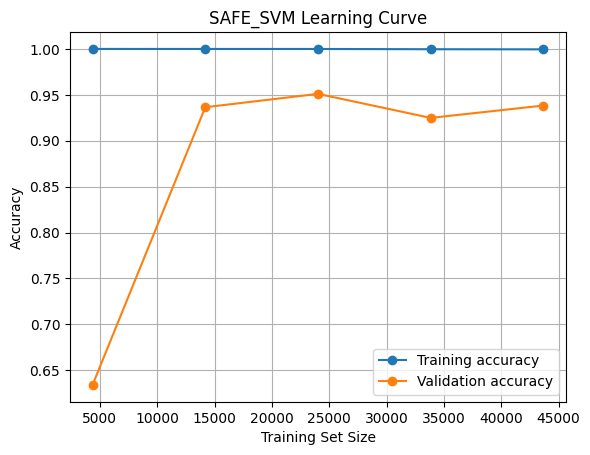

In [24]:
# ======================================================================
# 7. 실행
# ======================================================================
hand_file = 'mnist_final_balanced.npz'
org_file = 'mnist_sklearn_40000.npz'

X_tr, X_te, y_tr, y_te = load_preprocess_and_augment(hand_file, org_file)
X_aug, y_aug = augment_weak_classes(X_tr, y_tr)

# 🔥 모델 훈련 & 테스트 평가
best_model = run_experiment("SAFE_SVM", X_aug, X_te, y_aug, y_te)

# 📈 러닝 커브 분석
plot_learning_curve(best_model, X_aug, y_aug, title="SAFE_SVM Learning Curve")

📌 Final Test Accuracy: 0.9760


<Figure size 600x600 with 0 Axes>

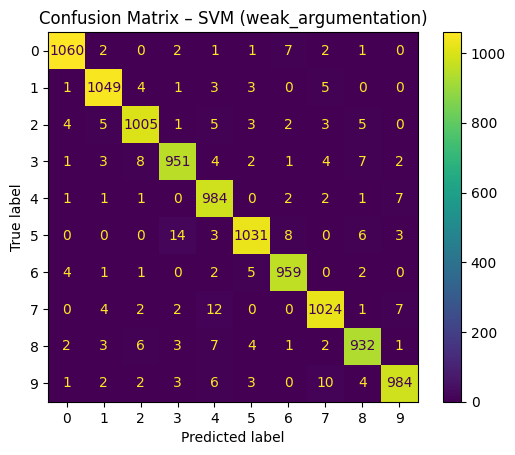

In [13]:
import joblib
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# 저장된 모델 로드
model = joblib.load("SAFE_SVM_final_model.joblib")

# 예측
y_pred = model.predict(X_te)

# 정확도 출력
print(f"📌 Final Test Accuracy: {accuracy_score(y_te, y_pred):.4f}")

# Confusion Matrix 출력
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.title("Confusion Matrix – SVM (weak_argumentation)")
plt.show()

추가 배포된 mnist23_1-32.zip 파일을 모으고 클리닝 진행한 파일 = 

In [9]:
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 저장된 모델 로드
model = joblib.load("SAFE_SVM_final_model.joblib")

# 2. 교수님 테스트 데이터 로드
data = np.load("combined_mnist_1to32.npz")
X_test = data["img"]
y_test = data["label"]

# 3. 이미지 형태 보정 (28x28 유지)
if X_test.ndim == 2:
    X_test = X_test.reshape(-1, 28, 28)

# 4. 🔥 직접 CustomImagePreprocess 적용 (Pipeline에 없음!)
preprocessor = CustomImagePreprocess()
X_test_pp = preprocessor.transform(X_test)  # (N, 784)

# 5. Scaling 적용 (Pipeline엔 scaler 포함되어 있음 👍)
X_test_pp = model.named_steps["scaler"].transform(X_test_pp)

# 6. 🔮 최종 예측
y_pred = model.named_steps["clf"].predict(X_test_pp)

# 7. 📊 최종 평가
print(f"\n🎯 Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred))
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


🎯 Final Test Accuracy: 0.8317

📌 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       950
           1       0.73      0.87      0.80       950
           2       0.87      0.85      0.86       950
           3       0.81      0.78      0.79       950
           4       0.84      0.86      0.85       950
           5       0.80      0.81      0.81       950
           6       0.85      0.86      0.86       950
           7       0.75      0.84      0.79       950
           8       0.94      0.77      0.85       950
           9       0.88      0.81      0.84       950

    accuracy                           0.83      9500
   macro avg       0.84      0.83      0.83      9500
weighted avg       0.84      0.83      0.83      9500


📊 Confusion Matrix:
[[818  33  12  16   5  25  22  16   1   2]
 [  7 831  22   7   5  15  13  43   2   5]
 [  6  53 806   8   9  23  20  18   6   1]
 [  8  35  15 740  13  36  24  47 